In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
pip install pgeocode

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pgeocode
from sklearn.preprocessing import LabelEncoder

IMPORTING DATASETS & PREPROCESSING

In [4]:
vehicle_msrp=pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/car_data.csv')
vehicles=pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/vehicles.csv')

In [5]:
ca_vehicles=vehicles[vehicles['state']=='ca']

In [6]:
import os
os.listdir('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData')

['vehicle-fuel-type-counts-2024.csv',
 'vehicle-fuel-type-count-by-zip-code-20231.csv',
 'vehicle-fuel-type-count-by-zip-code-2022.csv',
 'vehicle-fuel-type-count-by-zip-code-2021.csv',
 'vehicle-count-as-of-1-1-2020.csv',
 'vehicle-fuel-type-count-by-zip-code.csv']

In [7]:
reg_2024 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-counts-2024.csv')
reg_2024['year'] = 2024

reg_2023 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-20231.csv')
reg_2023['year'] = 2023

reg_2022 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2022.csv')
reg_2022['year'] = 2022

reg_2021 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2021.csv')
reg_2021['year'] = 2021

reg_2020 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-count-as-of-1-1-2020.csv')
reg_2020['year'] = 2020

reg_2019 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code.csv')
reg_2019['year'] = 2019

reg_2023.rename(columns={'ZIP Code': 'Zip Code'}, inplace=True)
reg_2024.rename(columns={'ZIP Code': 'Zip Code'}, inplace=True)

complete_reg = pd.concat([reg_2019, reg_2020, reg_2021, reg_2022, reg_2023, reg_2024], ignore_index=True)

print(complete_reg.shape)
print(complete_reg['year'].value_counts().sort_index())

/tmp/ipykernel_1991/3843566331.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2022 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2022.csv')
/tmp/ipykernel_1991/3843566331.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2021 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-fuel-type-count-by-zip-code-2021.csv')
/tmp/ipykernel_1991/3843566331.py:13: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2020 = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/RegData/vehicle-count-as-of-1-1-2020.csv')
/tmp/ipykernel_1991/3843566331.py:16: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  reg_2019 = pd.read_csv('/content/drive/MyDrive/Seni

(3632393, 8)
year
2019    586233
2020    602394
2021    677969
2022    767054
2023    499623
2024    499120
Name: count, dtype: int64


In [8]:
vehicles.shape

(426880, 26)

In [9]:
ca_vehicles.shape

(50614, 26)

In [10]:
complete_reg.shape

(3632393, 8)

In [11]:
complete_reg['Zip Code'].nunique()

9893

In [12]:
complete_reg['Make'].nunique()

160

In [13]:
complete_reg.shape

(3632393, 8)

VEHICLE_MSRP


In [14]:
#Vehicle_msrp
print(vehicle_msrp.columns.tolist())
print(vehicle_msrp.head())
print(vehicle_msrp.shape)

['Unnamed: 0', 'Model', 'Year', 'Status', 'Mileage', 'Price', 'MSRP']
   Unnamed: 0                                              Model  Year Status  \
0           0                              2022 Acura TLX A-Spec  2022    New   
1           1                              2023 Acura RDX A-Spec  2023    New   
2           2                              2023 Acura TLX Type S  2023    New   
3           3                              2023 Acura TLX Type S  2023    New   
4           4  2019 Acura MDX Sport Hybrid 3.0L w/Technology ...  2019   Used   

         Mileage    Price             MSRP  
0  Not available  $49,445     MSRP $49,445  
1  Not available  $50,895    Not specified  
2  Not available  $57,745    Not specified  
3  Not available  $57,545    Not specified  
4     32,675 mi.  $40,990  $600 price drop  
(115762, 7)


In [15]:
print(vehicle_msrp['Model'].nunique())

9216


In [16]:
#Preprocessing for vehicle_msrp dataset
# drop msrp column
vehicle_msrp = vehicle_msrp.drop(columns=['Unnamed: 0', 'MSRP'])

# clean price column
vehicle_msrp['Price'] = vehicle_msrp['Price'].str.replace('$', '').str.replace(',', '').str.strip()
vehicle_msrp['Price'] = pd.to_numeric(vehicle_msrp['Price'], errors='coerce')

# check
print(vehicle_msrp['Price'].dtype)

float64


In [17]:
#Dropping outliers for vehicle_msrp
vehicle_msrp = vehicle_msrp.dropna(subset=['Price'])

vehicle_msrp = vehicle_msrp[
    (vehicle_msrp['Price'] >= 15000) &
    (vehicle_msrp['Price'] <= 200000)
]

print(vehicle_msrp.shape)
print(vehicle_msrp['Price'].describe())

(108432, 5)
count    108432.000000
mean      52095.876992
std       29923.533801
min       15000.000000
25%       31988.000000
50%       44747.000000
75%       61999.000000
max      200000.000000
Name: Price, dtype: float64


In [18]:
print(vehicle_msrp['Price'].isnull().sum())

0


In [19]:
#Dropping the four digit year from Model column
vehicle_msrp['Model'] = vehicle_msrp['Model'].str.replace(r'^\d{4}\s', '', regex=True)
print(vehicle_msrp['Model'].head(10))

0                                    Acura TLX A-Spec
1                                    Acura RDX A-Spec
2                                    Acura TLX Type S
3                                    Acura TLX Type S
4    Acura MDX Sport Hybrid 3.0L w/Technology Package
5                                    Acura TLX A-Spec
6                                    Acura TLX A-Spec
7                                    Acura TLX Type S
8                                    Acura TLX A-Spec
9                                    Acura TLX A-Spec
Name: Model, dtype: object


In [20]:
#Formatting non numerical values to NaN
vehicle_msrp['Mileage'] = vehicle_msrp['Mileage'].str.replace(' mi.', '').str.replace(',', '').str.strip()
vehicle_msrp['Mileage'] = pd.to_numeric(vehicle_msrp['Mileage'], errors='coerce')

print(vehicle_msrp['Mileage'].describe())
print(vehicle_msrp['Mileage'].isnull().sum())

count     61199.000000
mean      41962.091374
std       31832.911103
min           0.000000
25%       18005.000000
50%       35563.000000
75%       59996.000000
max      974302.000000
Name: Mileage, dtype: float64
47233


In [21]:
#Dropping outliers in the 'Mileage' column
msrp_mileage = vehicle_msrp.dropna(subset=['Mileage'])
msrp_mileage = msrp_mileage[
    (msrp_mileage['Mileage'] > 0) &
    (msrp_mileage['Mileage'] <= 300000)
]

CA_VEHICLE

In [22]:
print(ca_vehicles['manufacturer'].unique().tolist())

['hyundai', 'toyota', 'mercedes-benz', 'harley-davidson', 'nissan', 'chevrolet', 'gmc', 'acura', 'volkswagen', 'subaru', 'mini', 'audi', 'ford', 'pontiac', 'lexus', 'chrysler', 'honda', 'ram', 'jeep', nan, 'kia', 'bmw', 'mazda', 'tesla', 'fiat', 'cadillac', 'dodge', 'infiniti', 'lincoln', 'buick', 'alfa-romeo', 'mitsubishi', 'volvo', 'datsun', 'rover', 'porsche', 'jaguar', 'mercury', 'saturn', 'ferrari', 'aston-martin', 'land rover']


In [23]:
#This checks how many rows are zero for the price column.
print(ca_vehicles[ca_vehicles['price'] == 0].shape[0])

5255


In [24]:
#Removes all the rows that has price = 0
ca_vehicles = ca_vehicles[ca_vehicles['price'] > 0]
print(ca_vehicles.shape)

(45359, 26)


In [25]:
#Removing Outliers
ca_vehicles = ca_vehicles[
    (ca_vehicles['price'] >= 500) & (ca_vehicles['price'] <= 150000) &
    (ca_vehicles['odometer'] >= 1000) & (ca_vehicles['odometer'] <= 300000) &
    (ca_vehicles['year'] >= 1990)
]

In [26]:
#Removing Unkown Makes from complete_reg
#complete_reg=complete_reg[complete_reg['Make'].isin(ca_vehicles['manufacturer'].unique())
complete_reg=complete_reg[complete_reg['Make'] != 'OTHER/UNK']

In [27]:
print(ca_vehicles[['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'size', 'type', 'state']].describe())

               price          year       odometer
count   40459.000000  40459.000000   40459.000000
mean    18934.534146   2011.935194   93561.688771
std     14365.384257      6.023973   59919.848621
min       500.000000   1990.000000    1000.000000
25%      8288.000000   2008.000000   42845.000000
50%     15500.000000   2013.000000   89000.000000
75%     26590.000000   2017.000000  132224.000000
max    149998.000000   2022.000000  300000.000000


In [28]:
print(ca_vehicles.columns.tolist())

['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


In [29]:
print(ca_vehicles[['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'size', 'type']].isnull().sum())

region              0
price               0
year                0
manufacturer     1253
model             283
condition       11675
fuel               43
odometer            0
title_status     1177
size            29893
type             7212
dtype: int64


COMPLETE_REG

In [30]:
print(complete_reg.columns.tolist())

['Date', 'Zip Code', 'Model Year', 'Fuel', 'Make', 'Duty', 'Vehicles', 'year']


In [31]:
print(complete_reg['Fuel'].value_counts())

Fuel
Gasoline                    1633629
Hybrid Gasoline              141525
Flex-Fuel                    135662
Diesel and Diesel Hybrid     112840
Battery Electric              54297
Plug-in Hybrid                37843
Unk                            9527
Natural Gas                    2554
Other                           899
Hydrogen Fuel Cell              545
Name: count, dtype: int64


In [32]:
complete_reg.dtypes

,0
Date,object
Zip Code,object
Model Year,object
Fuel,object
Make,object
Duty,object
Vehicles,int64
year,int64


In [33]:
print(reg_2024['Date'].value_counts())

Date
12/31/2024    499120
Name: count, dtype: int64


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

reg_encoded = complete_reg[['Vehicles', 'year', 'Fuel', 'Make', 'Duty']].copy()

cat_cols = ['Fuel', 'Make', 'Duty']
for col in cat_cols:
    reg_encoded[col] = le.fit_transform(reg_encoded[col].astype(str))

AGGREGATIONS AND EDA




CA_VEHICLES CORRELATION


In [35]:
correlation = ca_vehicles[['price', 'year', 'odometer']].corr()
print(correlation)

             price      year  odometer
price     1.000000  0.534602 -0.550472
year      0.534602  1.000000 -0.685637
odometer -0.550472 -0.685637  1.000000


COMPLETE_REG CORRELATION

In [36]:
correlation = reg_encoded.corr()
print(correlation['Vehicles'].sort_values(ascending=False))

Vehicles    1.000000
Make        0.053738
Duty        0.014551
Fuel        0.005111
year       -0.011182
Name: Vehicles, dtype: float64


AGGREGATIONS

In [37]:
#Aggregation
fuel_by_year = complete_reg.groupby(['year', 'Fuel'])['Vehicles'].sum().reset_index()
totals = fuel_by_year.groupby('year')['Vehicles'].transform('sum')
fuel_by_year['percentage'] = (fuel_by_year['Vehicles'] / totals * 100).round(2)
print(fuel_by_year.sort_values(['year', 'percentage'], ascending=[True, False]))

    year                      Fuel  Vehicles  percentage
3   2019                  Gasoline  25123712       90.06
2   2019                 Flex-Fuel   1010260        3.62
4   2019           Hybrid Gasoline    837218        3.00
1   2019  Diesel and Diesel Hybrid    672876        2.41
0   2019          Battery Electric    131977        0.47
8   2019            Plug-in Hybrid    104022        0.37
6   2019               Natural Gas     14851        0.05
7   2019                     Other      1893        0.01
5   2019        Hydrogen Fuel Cell      1025        0.00
12  2020                  Gasoline  25438107       89.88
11  2020                 Flex-Fuel    951281        3.36
13  2020           Hybrid Gasoline    867225        3.06
10  2020  Diesel and Diesel Hybrid    696855        2.46
9   2020          Battery Electric    215987        0.76
17  2020            Plug-in Hybrid    117162        0.41
15  2020               Natural Gas     13838        0.05
16  2020                     Ot

In [38]:
#Brand Demand
brand_demand = complete_reg.groupby(['Zip Code', 'Make'])['Vehicles'].sum().reset_index()
brand_demand.columns = ['Zip Code', 'Make', 'Total_registered']
print(brand_demand.head(30))


   Zip Code           Make  Total_registered
0     90000      CHEVROLET                53
1     90000          DODGE                11
2     90000           FORD                60
3     90000            GMC                31
4     90000       PLYMOUTH               118
5     90000            Unk                96
6     90000          WHITE                38
7     90001          ACURA               584
8     90001           AUDI                93
9     90001            BMW              1183
10    90001          BUICK               187
11    90001       CADILLAC               497
12    90001      CHEVROLET              8541
13    90001       CHRYSLER               726
14    90001          DODGE              2515
15    90001           FORD              6746
16    90001   FREIGHTLINER               309
17    90001            GEO                17
18    90001            GMC              1783
19    90001           HINO                11
20    90001          HONDA              8943
21    9000

In [39]:
top5_by_year = complete_reg.groupby(['year', 'Make'])['Vehicles'].sum().reset_index()
top5_by_year = top5_by_year.groupby('year').apply(lambda x: x.nlargest(5, 'Vehicles')).reset_index(drop=True)
print(top5_by_year)

    year       Make  Vehicles
0   2019     TOYOTA   5527557
1   2019      HONDA   3492287
2   2019       FORD   3432046
3   2019  CHEVROLET   2777281
4   2019     NISSAN   1917892
5   2020     TOYOTA   5551796
6   2020      HONDA   3550572
7   2020       FORD   3339030
8   2020  CHEVROLET   2662345
9   2020     NISSAN   1911398
10  2021     TOYOTA   5557148
11  2021      HONDA   3477239
12  2021       FORD   2875007
13  2021  CHEVROLET   2468783
14  2021     NISSAN   1764332
15  2022     TOYOTA   5707406
16  2022      HONDA   3465385
17  2022       FORD   2956187
18  2022  CHEVROLET   2517393
19  2022     NISSAN   1697805
20  2023     TOYOTA   4694170
21  2023      HONDA   2937443
22  2023       FORD   1552989
23  2023  CHEVROLET   1416435
24  2023     NISSAN   1066246
25  2024     TOYOTA   4721140
26  2024      HONDA   2922932
27  2024       FORD   1487642
28  2024  CHEVROLET   1365633
29  2024     NISSAN   1006732


/tmp/ipykernel_1991/1633089214.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top5_by_year = top5_by_year.groupby('year').apply(lambda x: x.nlargest(5, 'Vehicles')).reset_index(drop=True)


In [40]:
# get the unique top 5 makes across all years
top5_makes = top5_by_year['Make'].unique()

# filter complete_reg to only those makes and main fuel types
main_fuels = ['Gasoline', 'Battery Electric', 'Hybrid Gasoline', 'Plug-in Hybrid', 'Diesel and Diesel Hybrid']

filtered_reg = complete_reg[
    (complete_reg['Make'].isin(top5_makes)) &
    (complete_reg['Fuel'].isin(main_fuels))
]

# aggregate by year, make and fuel
zip_brand_fuel = filtered_reg.groupby(['year', 'Make', 'Fuel'])['Vehicles'].sum().reset_index()

print(zip_brand_fuel.head(20))

    year       Make                      Fuel  Vehicles
0   2019  CHEVROLET          Battery Electric     14677
1   2019  CHEVROLET  Diesel and Diesel Hybrid     55933
2   2019  CHEVROLET                  Gasoline   2281134
3   2019  CHEVROLET           Hybrid Gasoline       334
4   2019  CHEVROLET            Plug-in Hybrid     38349
5   2019       FORD          Battery Electric       737
6   2019       FORD  Diesel and Diesel Hybrid    235805
7   2019       FORD                  Gasoline   2710795
8   2019       FORD           Hybrid Gasoline     38259
9   2019       FORD            Plug-in Hybrid     19919
10  2019      HONDA          Battery Electric       235
11  2019      HONDA                  Gasoline   3451887
12  2019      HONDA           Hybrid Gasoline     36292
13  2019      HONDA            Plug-in Hybrid      2430
14  2019     NISSAN          Battery Electric     13711
15  2019     NISSAN  Diesel and Diesel Hybrid        25
16  2019     NISSAN                  Gasoline   

In [41]:
region_price = ca_vehicles.groupby('region')['price'].mean().sort_values(ascending=False).reset_index()
print(region_price.head(20))

              region         price
0    imperial county  37385.245902
1        bakersfield  27986.760502
2     visalia-tulare  26130.753561
3   hanford-corcoran  25882.233333
4        santa maria  23181.164882
5         susanville  21608.487179
6       monterey bay  21444.309826
7      santa barbara  20731.164399
8    humboldt county  20638.932203
9            redding  20393.391160
10      reno / tahoe  20001.436502
11            merced  19415.902622
12   fresno / madera  19310.700437
13             chico  19249.387146
14       SF bay area  18986.893546
15     orange county  18507.376024
16          stockton  18404.618483
17   san luis obispo  18339.330240
18      gold country  17918.097682
19        sacramento  17545.741316


In [42]:
region_fuel_price = ca_vehicles.groupby(['region', 'fuel'])['price'].mean().reset_index()
print(region_fuel_price.head(20))

             region      fuel         price
0       SF bay area    diesel  31752.469880
1       SF bay area  electric  23449.441176
2       SF bay area       gas  17891.549975
3       SF bay area    hybrid  16296.232558
4       SF bay area     other  24382.304762
5       bakersfield    diesel  45042.664723
6       bakersfield  electric  29553.000000
7       bakersfield       gas  22172.476346
8       bakersfield    hybrid  23037.466667
9       bakersfield     other  33579.707113
10            chico    diesel  32491.209302
11            chico  electric  30668.400000
12            chico       gas  17546.752995
13            chico    hybrid  14813.772727
14            chico     other  26121.403670
15  fresno / madera    diesel  37197.734266
16  fresno / madera  electric  20699.714286
17  fresno / madera       gas  17827.706030
18  fresno / madera    hybrid  13004.214286
19  fresno / madera     other  27791.813953


In [43]:
#IMPORTANT MEASURES SUMMARY
#NUMERICAL COLUMNS
print("ca_vehicles:")
print(ca_vehicles[['price', 'odometer', 'year']].describe())

print("\nvehicle_msrp:")
print(vehicle_msrp[['Price', 'Year', 'Mileage']].describe())

print("\ncomplete_reg:")
print(complete_reg[['Vehicles', 'year']].describe())

ca_vehicles:
               price       odometer          year
count   40459.000000   40459.000000  40459.000000
mean    18934.534146   93561.688771   2011.935194
std     14365.384257   59919.848621      6.023973
min       500.000000    1000.000000   1990.000000
25%      8288.000000   42845.000000   2008.000000
50%     15500.000000   89000.000000   2013.000000
75%     26590.000000  132224.000000   2017.000000
max    149998.000000  300000.000000   2022.000000

vehicle_msrp:
               Price           Year        Mileage
count  108432.000000  108432.000000   61199.000000
mean    52095.876992    2020.181736   41962.091374
std     29923.533801       3.960148   31832.911103
min     15000.000000    1949.000000       0.000000
25%     31988.000000    2019.000000   18005.000000
50%     44747.000000    2022.000000   35563.000000
75%     61999.000000    2023.000000   59996.000000
max    200000.000000    2023.000000  974302.000000

complete_reg:
           Vehicles          year
count  2.12932

In [44]:
#IMPORTANT MEASURES SUMMARY
#CATEGORICAL COLUMNS
print(ca_vehicles['condition'].value_counts())
print(ca_vehicles['fuel'].value_counts())
print(ca_vehicles['manufacturer'].value_counts().head(10))

condition
excellent    14145
good         11880
like new      2064
fair           534
salvage         83
new             78
Name: count, dtype: int64
fuel
gas         33888
other        2912
diesel       2393
hybrid        919
electric      304
Name: count, dtype: int64
manufacturer
ford             5660
toyota           4472
chevrolet        4195
honda            2728
nissan           2154
bmw              1867
mercedes-benz    1608
ram              1383
hyundai          1250
jeep             1193
Name: count, dtype: int64


VISUALIZATIONS & PLOTS


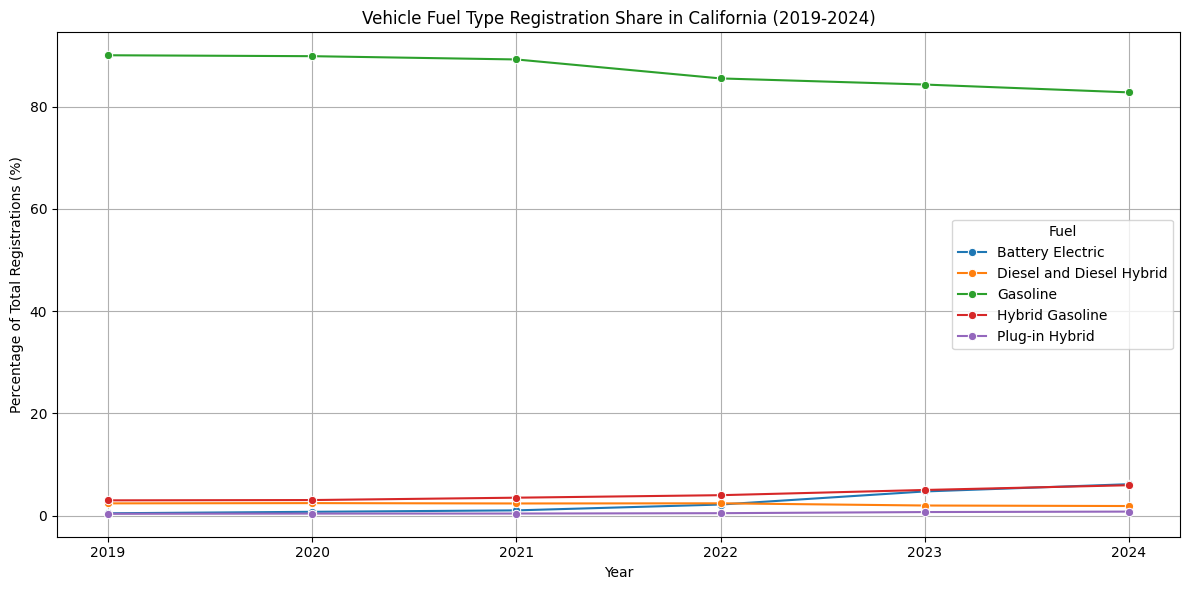

In [45]:
#First Plot for complete_reg
main_fuels = ['Gasoline', 'Battery Electric', 'Hybrid Gasoline', 'Plug-in Hybrid', 'Diesel and Diesel Hybrid']
filtered = fuel_by_year[fuel_by_year['Fuel'].isin(main_fuels)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=filtered, x='year', y='percentage', hue='Fuel', marker='o')

plt.title('Vehicle Fuel Type Registration Share in California (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Percentage of Total Registrations (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

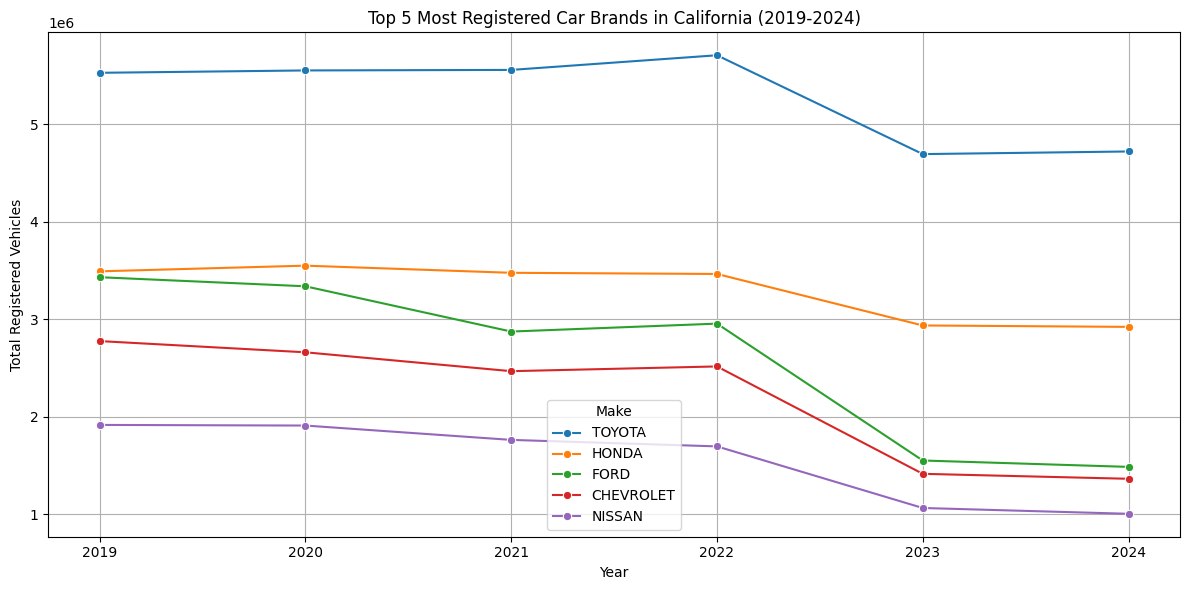

In [46]:
#Second Plot for Top 5 Most Registered Vehicle Brand from 2019 to 2024

plt.figure(figsize=(12, 6))
sns.lineplot(data=top5_by_year, x='year', y='Vehicles', hue='Make', marker='o')

plt.title('Top 5 Most Registered Car Brands in California (2019-2024)')
plt.xlabel('Year')
plt.ylabel('Total Registered Vehicles')
plt.grid(True)
plt.tight_layout()
plt.show()

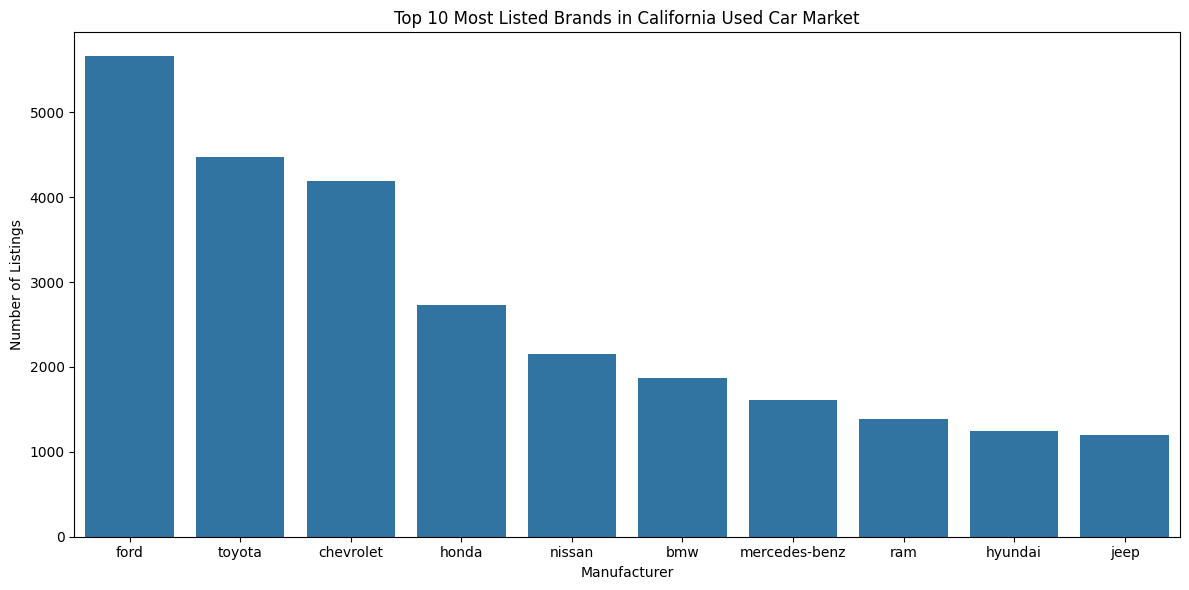

In [47]:
top10_brands = ca_vehicles['manufacturer'].value_counts().head(10).reset_index()
top10_brands.columns = ['manufacturer', 'count']

plt.figure(figsize=(12, 6))
sns.barplot(data=top10_brands, x='manufacturer', y='count')

plt.title('Top 10 Most Listed Brands in California Used Car Market')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Listings')
plt.tight_layout()
plt.show()

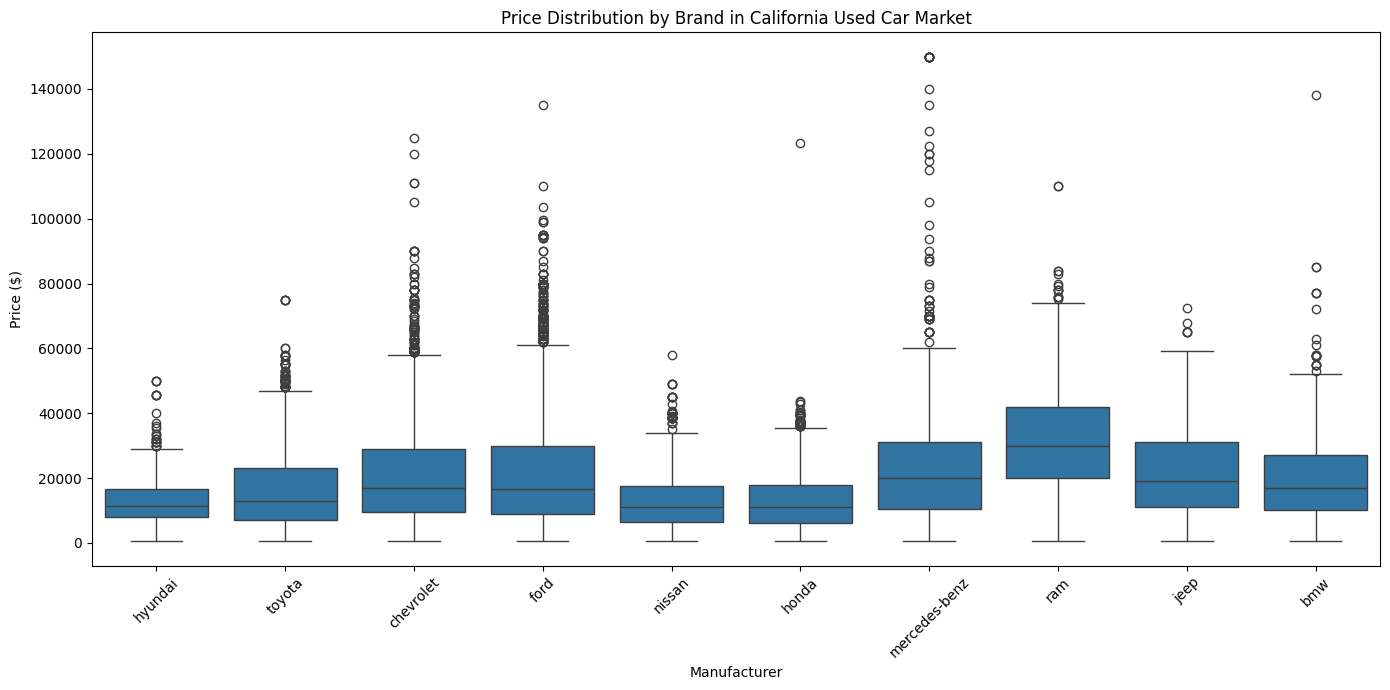

In [48]:
top10_list = top10_brands['manufacturer'].tolist()
top10_data = ca_vehicles[ca_vehicles['manufacturer'].isin(top10_list)]

plt.figure(figsize=(14, 7))
sns.boxplot(data=top10_data, x='manufacturer', y='price')

plt.title('Price Distribution by Brand in California Used Car Market')
plt.xlabel('Manufacturer')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CORRELATIONS PLOTS


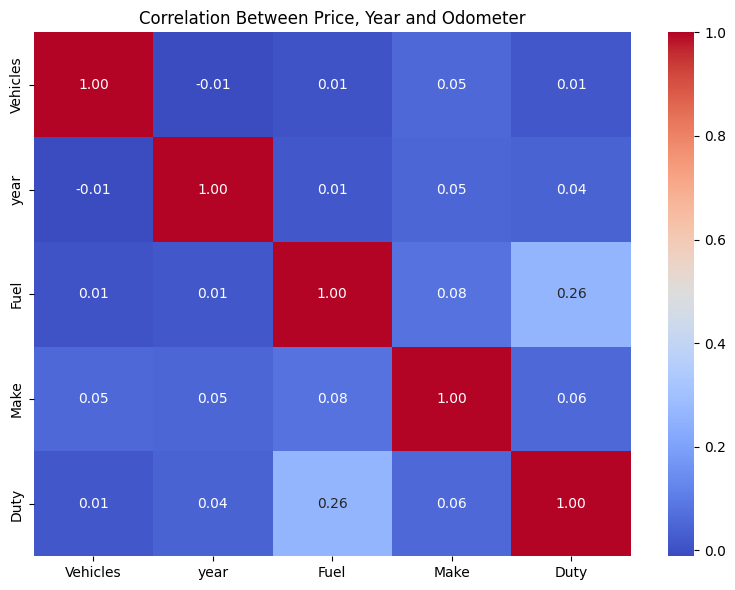

In [49]:
#Heatmap for Correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Between Price, Year and Odometer')
plt.tight_layout()
plt.show()

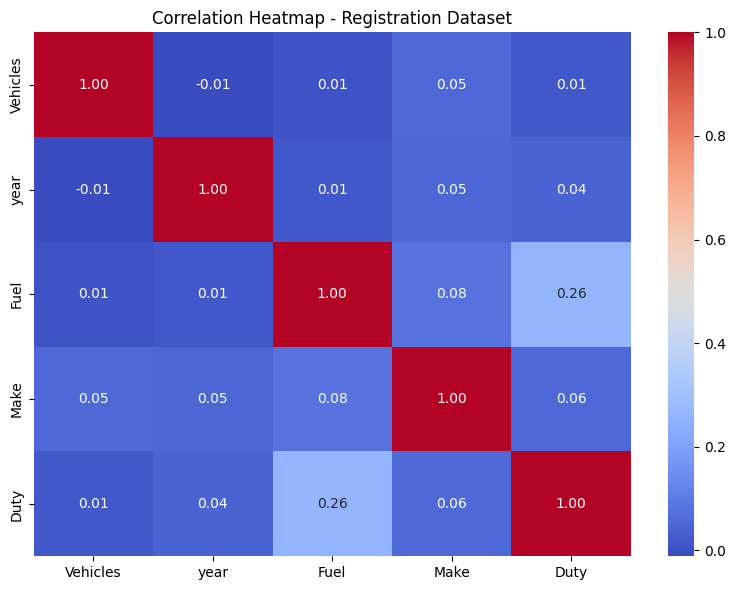

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Registration Dataset')
plt.tight_layout()
plt.show()

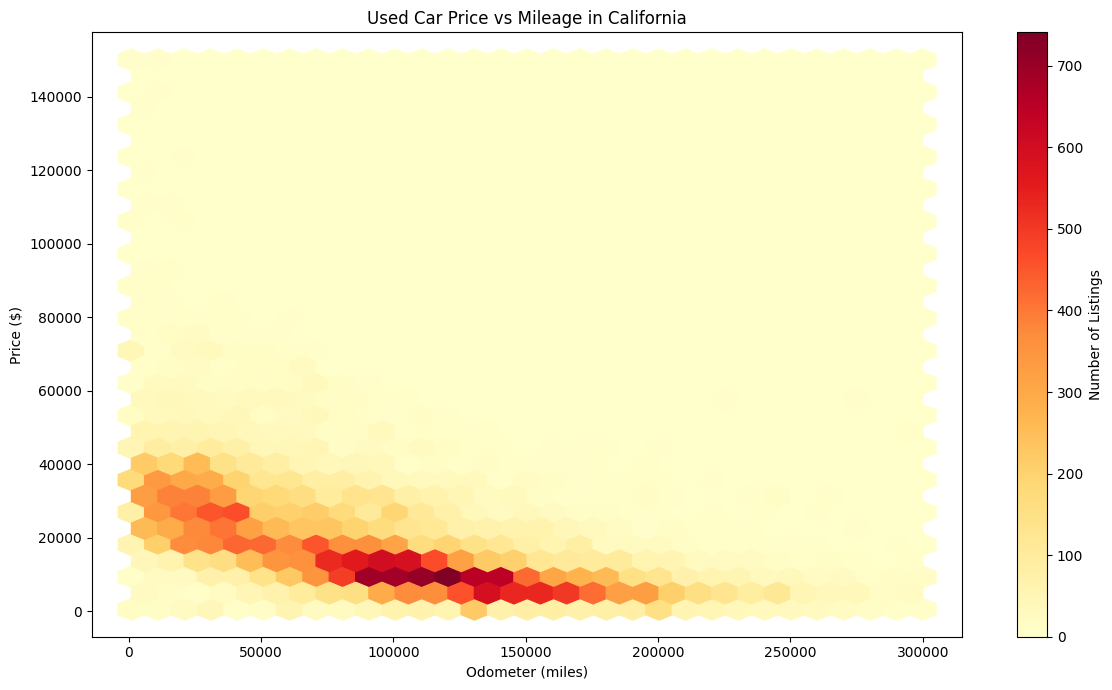

In [51]:
plt.figure(figsize=(12, 7))
plt.hexbin(ca_vehicles['odometer'], ca_vehicles['price'], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Number of Listings')

plt.title('Used Car Price vs Mileage in California')
plt.xlabel('Odometer (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

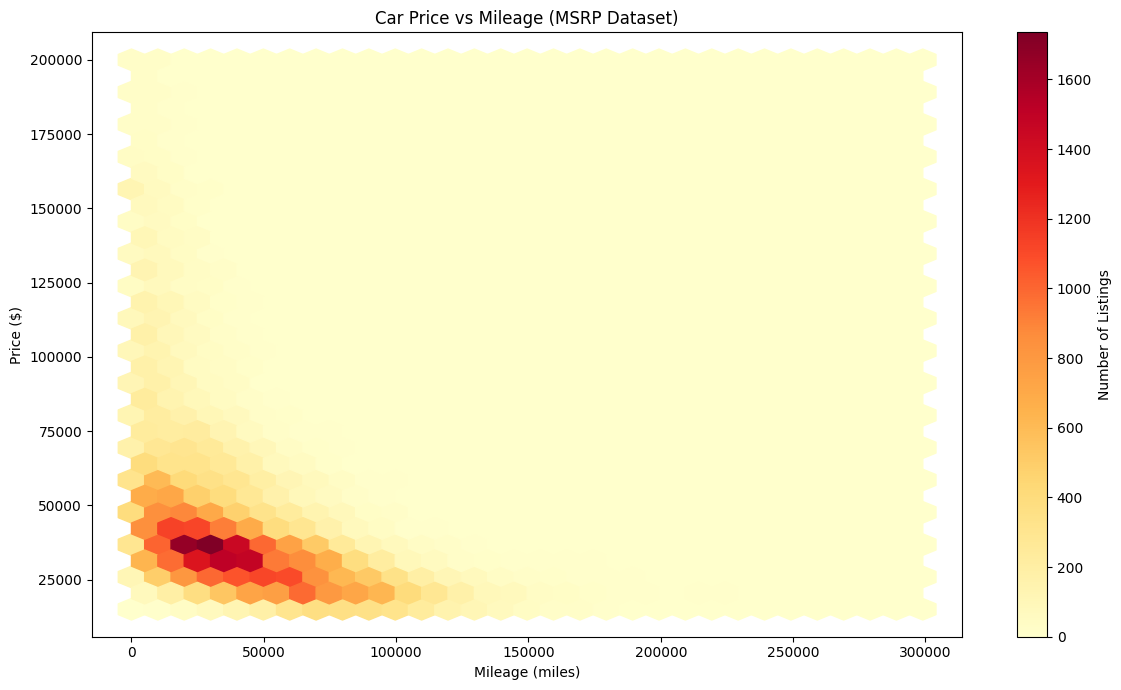

In [52]:
plt.figure(figsize=(12, 7))
plt.hexbin(msrp_mileage['Mileage'], msrp_mileage['Price'], gridsize=30, cmap='YlOrRd')
plt.colorbar(label='Number of Listings')

plt.title('Car Price vs Mileage (MSRP Dataset)')
plt.xlabel('Mileage (miles)')
plt.ylabel('Price ($)')
plt.tight_layout()
plt.show()

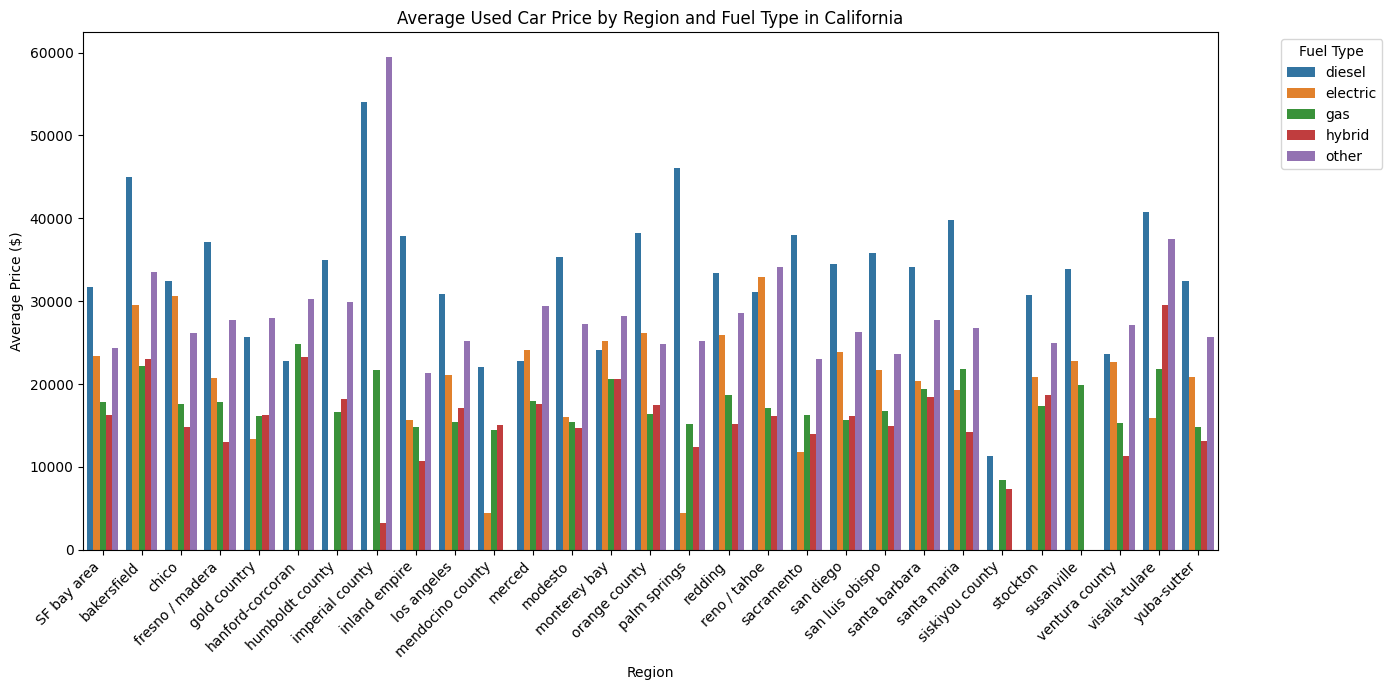

In [53]:
plt.figure(figsize=(14, 7))
sns.barplot(data=region_fuel_price, x='region', y='price', hue='fuel')

plt.title('Average Used Car Price by Region and Fuel Type in California')
plt.xlabel('Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

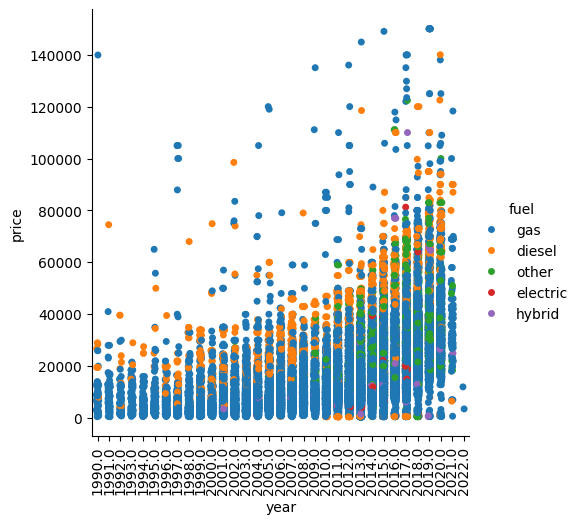

In [54]:
g=sns.catplot(data=ca_vehicles, x='year', y='price', hue='fuel')
g.set_xticklabels(rotation=90)

<Axes: xlabel='year', ylabel='price'>

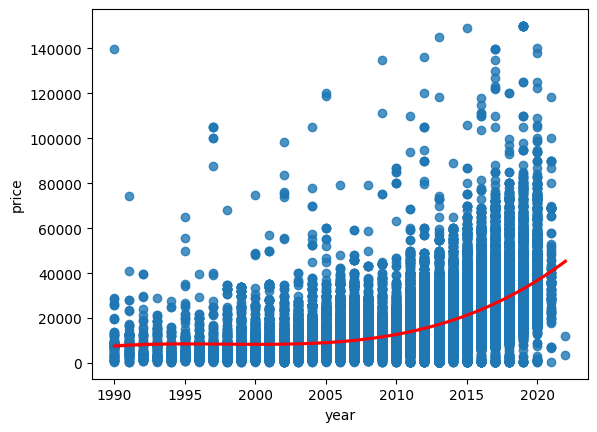

In [55]:
sns.regplot(data=ca_vehicles, x='year', y='price', order=3, line_kws={'color': 'red'})

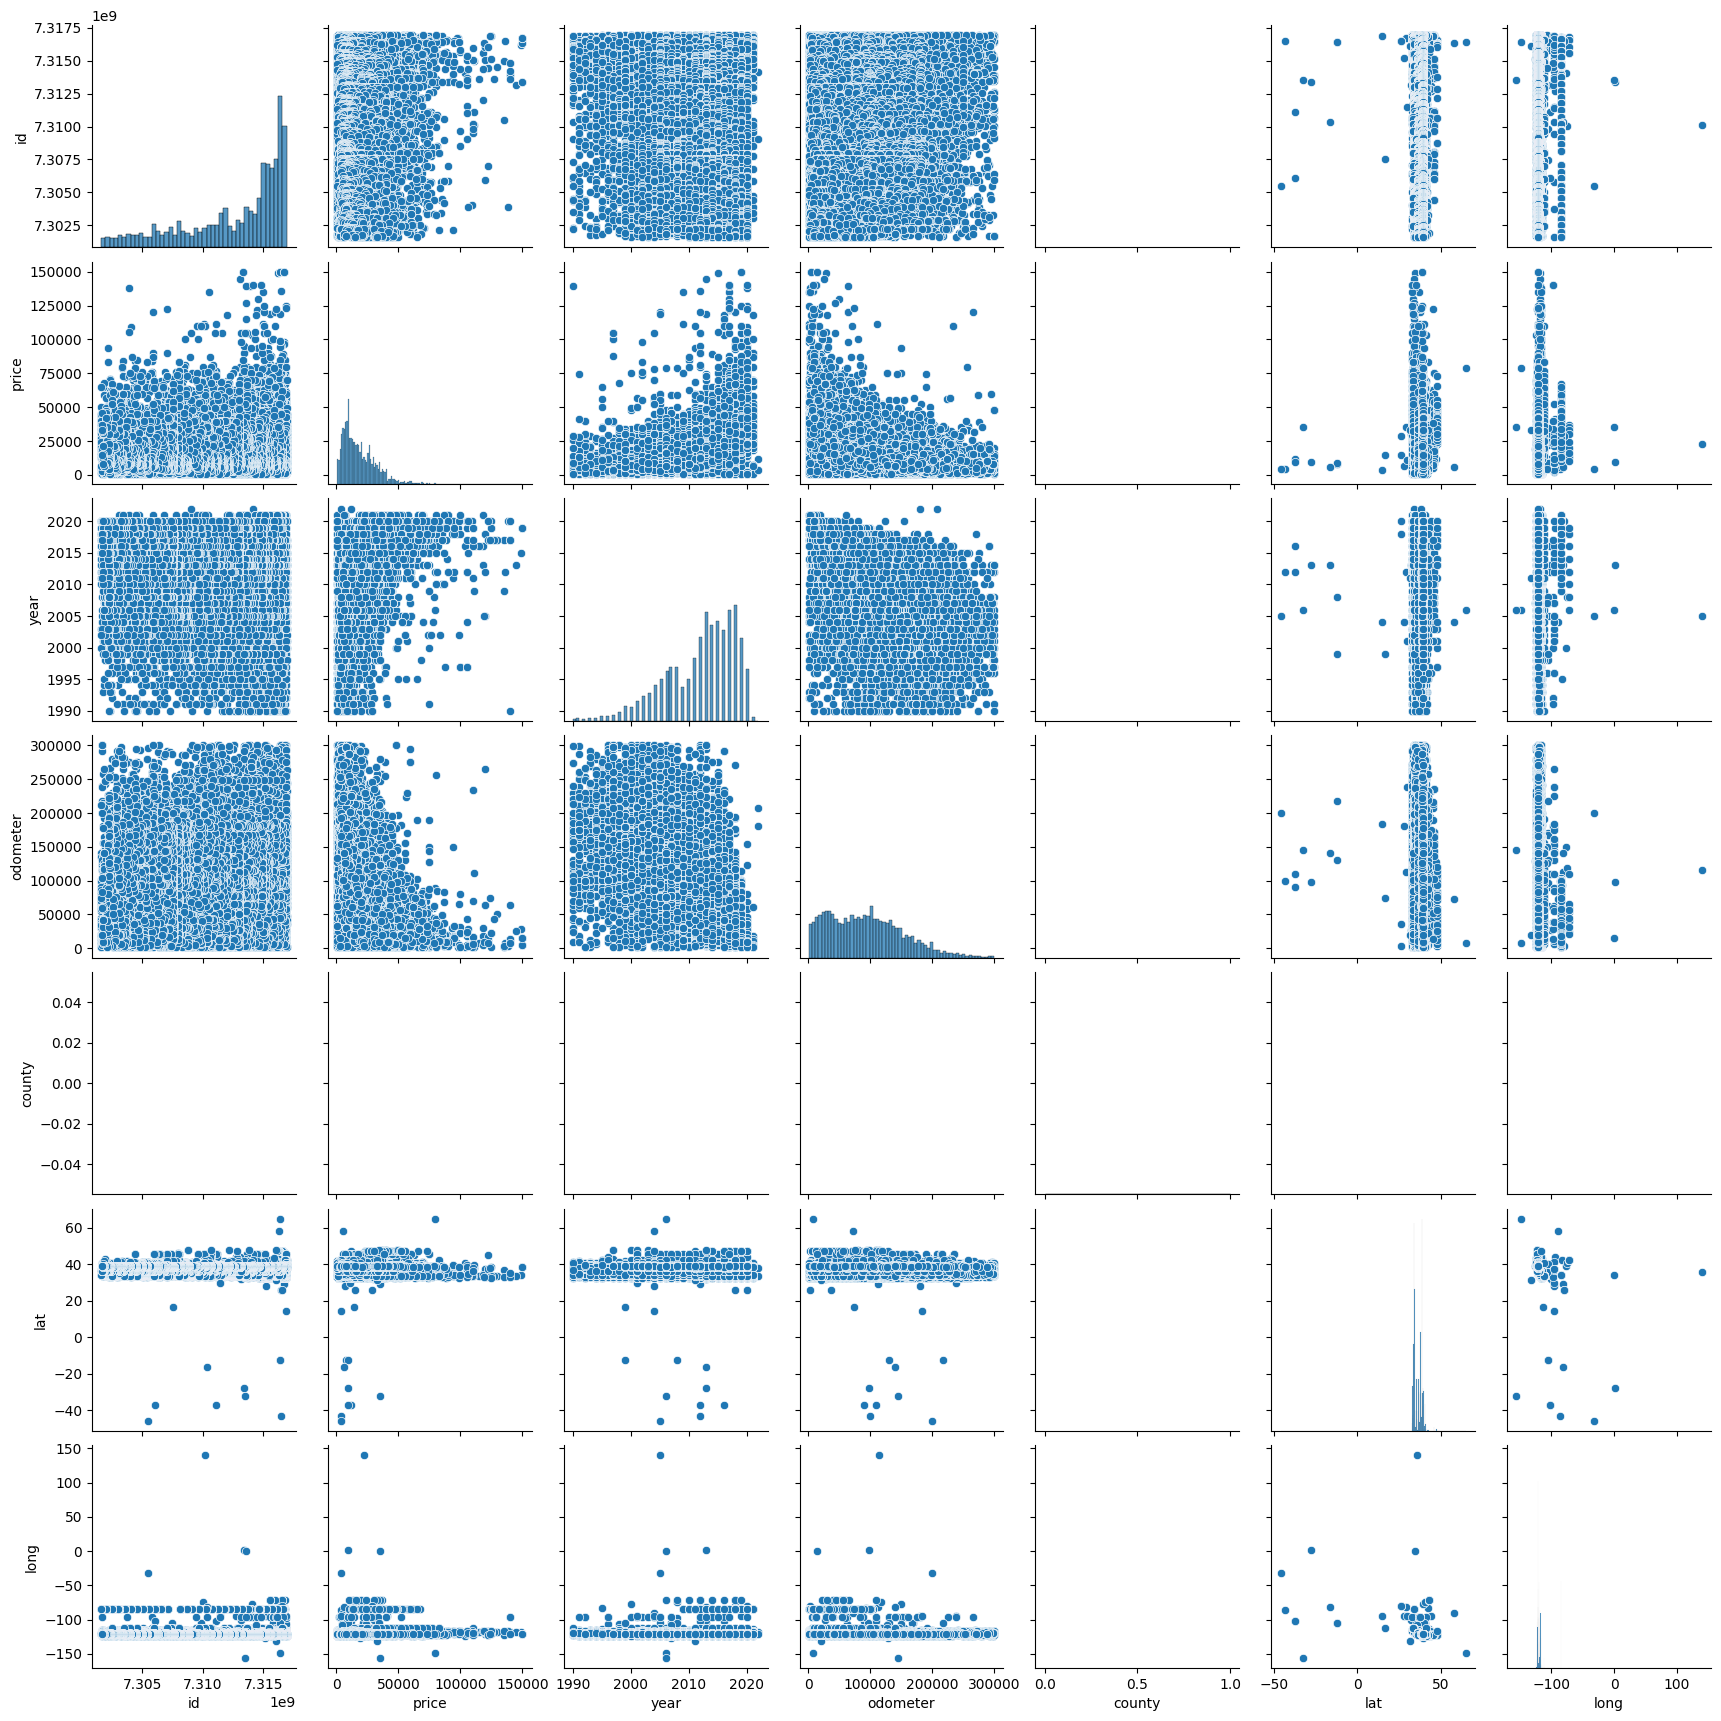

In [56]:
sns.pairplot(ca_vehicles)

Checking Which Make and Model are in both ca_vehicle & vehicle_msrp dataset

In [57]:
vehicle_msrp['make'] = vehicle_msrp['Model'].str.split().str[0].str.lower()
print(vehicle_msrp['make'].value_counts().head(20))

make
mercedes-benz    9900
chevrolet        9588
bmw              9390
lexus            9384
porsche          9274
tesla            9066
dodge            8914
volkswagen       8799
acura            8670
infiniti         8070
hyundai          7413
toyota           5554
ford             4410
Name: count, dtype: int64


In [58]:
msrp_makes = set(vehicle_msrp['make'].unique())
vehicle_makes = set(ca_vehicles['manufacturer'].unique())

# in both datasets
common = msrp_makes & vehicle_makes

# in msrp but not in ca_vehicles
msrp_only = msrp_makes - vehicle_makes

# in ca_vehicles but not in msrp
vehicles_only = vehicle_makes - msrp_makes

print("Common makes:", common)
print("\nIn MSRP only:", msrp_only)
print("\nIn ca_vehicles only:", vehicles_only)

Common makes: {'lexus', 'acura', 'dodge', 'bmw', 'toyota', 'mercedes-benz', 'infiniti', 'volkswagen', 'tesla', 'chevrolet', 'porsche', 'ford', 'hyundai'}

In MSRP only: set()

In ca_vehicles only: {'audi', 'honda', 'lincoln', 'rover', 'volvo', 'mercury', 'chrysler', nan, 'saturn', 'alfa-romeo', 'jaguar', 'kia', 'ferrari', 'nissan', 'gmc', 'jeep', 'mazda', 'cadillac', 'harley-davidson', 'mitsubishi', 'pontiac', 'subaru', 'ram', 'mini', 'land rover', 'aston-martin', 'buick', 'fiat'}


In [59]:
brand_proxy = {
    'honda': 'toyota',
    'nissan': 'hyundai',
    'mazda': 'toyota',
    'subaru': 'toyota',
    'kia': 'hyundai',
    'audi': 'bmw',
    'volvo': 'mercedes-benz',
    'jeep': 'ford',
    'ram': 'ford',
    'gmc': 'chevrolet',
    'cadillac': 'mercedes-benz',
    'buick': 'chevrolet',
    'lincoln': 'ford',
    'chrysler': 'dodge',
}

In [60]:
ca_vehicles.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
21171,7316895739,https://bakersfield.craigslist.org/ctd/d/baker...,bakersfield,https://bakersfield.craigslist.org,16990,2018.0,hyundai,accent se sedan 4d,good,NaN,...,NaN,sedan,white,https://images.craigslist.org/00k0k_2G5SBDPenD...,Carvana is the safer way to buy a car During t...,NaN,ca,35.380000,-119.020000,2021-05-04T12:41:15-0700
21172,7316894967,https://bakersfield.craigslist.org/cto/d/tehac...,bakersfield,https://bakersfield.craigslist.org,3700,2004.0,toyota,highlander,good,6 cylinders,...,NaN,NaN,NaN,https://images.craigslist.org/01313_dTUjBqHGgj...,"Runs Good,Brand New Tires,Tags are Current til...",NaN,ca,35.132200,-118.449000,2021-05-04T12:40:04-0700
21174,7316887125,https://bakersfield.craigslist.org/ctd/d/bloom...,bakersfield,https://bakersfield.craigslist.org,11975,2003.0,harley-davidson,davidson,excellent,8 cylinders,...,full-size,pickup,black,https://images.craigslist.org/00F0F_eEBhgvA15M...,MANAGER'S SPECIAL!!! *****💰💰💰🤑 >HUGE TAX SALE...,NaN,ca,34.070612,-117.383384,2021-05-04T12:26:43-0700
21176,7316874004,https://bakersfield.craigslist.org/ctd/d/stant...,bakersfield,https://bakersfield.craigslist.org,21950,2003.0,chevrolet,silverado 3500,excellent,8 cylinders,...,full-size,truck,grey,https://images.craigslist.org/00m0m_9owDGrPLWK...,Call 949-652-3373 SE HABLA ESPAÑOL SEE WHAT ...,NaN,ca,33.794656,-117.992994,2021-05-04T12:04:51-0700
21178,7316859625,https://bakersfield.craigslist.org/ctd/d/baker...,bakersfield,https://bakersfield.craigslist.org,27590,2018.0,acura,tlx 3.5 sedan 4d,good,6 cylinders,...,NaN,sedan,black,https://images.craigslist.org/00r0r_cyO57DXDL0...,Carvana is the safer way to buy a car During t...,NaN,ca,35.380000,-119.020000,2021-05-04T11:41:04-0700


In [61]:
ca_vehicles['region'].unique().tolist()

['bakersfield',
 'chico',
 'fresno / madera',
 'gold country',
 'hanford-corcoran',
 'humboldt county',
 'imperial county',
 'inland empire',
 'los angeles',
 'mendocino county',
 'merced',
 'modesto',
 'monterey bay',
 'orange county',
 'palm springs',
 'redding',
 'reno / tahoe',
 'sacramento',
 'san diego',
 'san luis obispo',
 'santa barbara',
 'santa maria',
 'SF bay area',
 'siskiyou county',
 'stockton',
 'susanville',
 'ventura county',
 'visalia-tulare',
 'yuba-sutter']

In [62]:
print(complete_reg['Zip Code'].nunique())
print(complete_reg['Zip Code'].unique()[:20])

4288
[90000 90001 90002 90003 90004 90005 90006 90007 90008 90009 90010 90011
 90012 90013 90014 90015 90016 90017 90018 90019]


In [63]:
import pgeocode

nomi = pgeocode.Nominatim('us')

unique_zips = complete_reg['Zip Code'].unique().tolist()

results = []
for zip_code in unique_zips:
    try:
        result = nomi.query_postal_code(str(zip_code))
        results.append({
            'Zip Code': zip_code,
            'city': result['place_name'],
            'county': result['county_name']
        })
    except:
        results.append({
            'Zip Code': zip_code,
            'city': None,
            'county': None
        })

zip_mapping = pd.DataFrame(results)
print(zip_mapping.head(20))
print(zip_mapping.shape)

   Zip Code         city       county
0     90000          NaN          NaN
1     90001  Los Angeles  Los Angeles
2     90002  Los Angeles  Los Angeles
3     90003  Los Angeles  Los Angeles
4     90004  Los Angeles  Los Angeles
5     90005  Los Angeles  Los Angeles
6     90006  Los Angeles  Los Angeles
7     90007  Los Angeles  Los Angeles
8     90008  Los Angeles  Los Angeles
9     90009  Los Angeles  Los Angeles
10    90010  Los Angeles  Los Angeles
11    90011  Los Angeles  Los Angeles
12    90012  Los Angeles  Los Angeles
13    90013  Los Angeles  Los Angeles
14    90014  Los Angeles  Los Angeles
15    90015  Los Angeles  Los Angeles
16    90016  Los Angeles  Los Angeles
17    90017  Los Angeles  Los Angeles
18    90018  Los Angeles  Los Angeles
19    90019  Los Angeles  Los Angeles
(4288, 3)


In [64]:
test = nomi.query_postal_code('90001')
print(test)

postal_code             90001
country_code               US
place_name        Los Angeles
state_name         California
state_code                 CA
county_name       Los Angeles
county_code              37.0
community_name           None
community_code            NaN
latitude              33.9731
longitude           -118.2479
accuracy                  4.0
Name: 0, dtype: object


In [65]:
print(zip_mapping['county'].value_counts())

county
Los Angeles       816
San Diego         330
Orange            271
San Bernardino    211
Riverside         194
                 ... 
Franklin            1
Curry               1
Josephine           1
Lane                1
Snohomish           1
Name: count, Length: 71, dtype: int64


In [66]:
#Filtering CA counties only
ca_zip_mapping = zip_mapping[zip_mapping['county'].notna()].copy()

# keep only california zipcodes using pgeocode state info
unique_zips = complete_reg['Zip Code'].unique().tolist()

results = []
for zip_code in unique_zips:
    try:
        result = nomi.query_postal_code(str(zip_code))
        if result['state_code'] == 'CA':
            results.append({
                'Zip Code': zip_code,
                'city': result['place_name'],
                'county': result['county_name'],
                'state': result['state_code']
            })
    except:
        pass

ca_zip_mapping = pd.DataFrame(results)
print(ca_zip_mapping['county'].value_counts())
print(ca_zip_mapping.shape)

county
Los Angeles                         816
San Diego                           330
Orange                              271
San Bernardino                      211
Riverside                           194
Santa Clara                         182
Fresno                              133
Kern                                127
Alameda                             116
Contra Costa                         96
Sonoma                               96
Sacramento                           91
Ventura                              84
San Joaquin                          79
Santa Barbara                        78
Humboldt                             76
Marin                                75
Tulare                               74
San Mateo                            72
City and County of San Francisco     70
Monterey                             67
San Luis Obispo                      65
Mendocino                            56
Stanislaus                           54
Merced                           

In [67]:
county_to_region = {
    # Los Angeles
    'Los Angeles': 'los angeles',

    # San Diego
    'San Diego': 'san diego',

    # Orange County
    'Orange': 'orange county',

    # Inland Empire
    'San Bernardino': 'inland empire',
    'Riverside': 'inland empire',

    # SF Bay Area
    'Santa Clara': 'SF bay area',
    'Alameda': 'SF bay area',
    'Contra Costa': 'SF bay area',
    'Marin': 'SF bay area',
    'San Mateo': 'SF bay area',
    'City and County of San Francisco': 'SF bay area',
    'Santa Cruz': 'SF bay area',
    'Napa': 'SF bay area',
    'Solano': 'SF bay area',

    # Sacramento
    'Sacramento': 'sacramento',
    'Yolo': 'sacramento',
    'Placer': 'sacramento',
    'El Dorado': 'gold country',
    'Amador': 'gold country',
    'Calaveras': 'gold country',
    'Tuolumne': 'gold country',
    'Mariposa': 'gold country',

    # Fresno / Madera
    'Fresno': 'fresno / madera',
    'Madera': 'fresno / madera',

    # Bakersfield
    'Kern': 'bakersfield',

    # Ventura
    'Ventura': 'ventura county',

    # Santa Barbara
    'Santa Barbara': 'santa barbara',

    # San Luis Obispo
    'San Luis Obispo': 'san luis obispo',

    # Santa Maria
    'Santa Maria': 'santa maria',

    # Monterey Bay
    'Monterey': 'monterey bay',

    # Stockton
    'San Joaquin': 'stockton',

    # Modesto
    'Stanislaus': 'modesto',

    # Merced
    'Merced': 'merced',

    # Visalia Tulare
    'Tulare': 'visalia-tulare',
    'Kings': 'hanford-corcoran',

    # Humboldt
    'Humboldt': 'humboldt county',
    'Trinity': 'humboldt county',

    # Mendocino
    'Mendocino': 'mendocino county',
    'Lake': 'mendocino county',

    # Redding
    'Shasta': 'redding',
    'Tehama': 'redding',

    # Chico
    'Butte': 'chico',
    'Glenn': 'chico',
    'Colusa': 'chico',

    # Yuba Sutter
    'Yuba': 'yuba-sutter',
    'Sutter': 'yuba-sutter',

    # Susanville
    'Lassen': 'susanville',
    'Plumas': 'susanville',

    # Siskiyou
    'Siskiyou': 'siskiyou county',
    'Modoc': 'siskiyou county',

    # Imperial
    'Imperial': 'imperial county',

    # Palm Springs
    'Inyo': 'palm springs',
    'Mono': 'palm springs',

    # Sonoma (closest to reno/tahoe or SF bay area)
    'Sonoma': 'SF bay area',

    # Nevada county
    'Nevada': 'gold country',
    'Sierra': 'gold country',

    # San Benito
    'San Benito': 'monterey bay',

    # Alpine
    'Alpine': 'gold country',

    # Del Norte
    'Del Norte': 'humboldt county',

    # Mariposa
    'San Bernardino': 'inland empire',
}

In [68]:
ca_zip_mapping['region'] = ca_zip_mapping['county'].map(county_to_region)

print(ca_zip_mapping['region'].value_counts())
print(ca_zip_mapping['region'].isnull().sum())

region
los angeles         816
SF bay area         801
inland empire       405
san diego           330
orange county       271
fresno / madera     157
gold country        151
sacramento          151
bakersfield         127
humboldt county     102
mendocino county     86
ventura county       84
stockton             79
santa barbara        78
monterey bay         77
visalia-tulare       74
san luis obispo      65
modesto              54
merced               42
redding              42
chico                36
imperial county      36
siskiyou county      33
palm springs         31
susanville           27
yuba-sutter          22
hanford-corcoran     18
Name: count, dtype: int64
0


In [69]:
# make sure Zip Code is string in both dataframes
complete_reg['Zip Code'] = complete_reg['Zip Code'].astype(str)
ca_zip_mapping['Zip Code'] = ca_zip_mapping['Zip Code'].astype(str)

# merge region into complete_reg
complete_reg = complete_reg.merge(ca_zip_mapping[['Zip Code', 'region']], on='Zip Code', how='left')

print(complete_reg['region'].value_counts())
print(complete_reg['region'].isnull().sum())

region
los angeles         1003767
SF bay area          874320
inland empire        466619
san diego            357713
orange county        353663
sacramento           152161
fresno / madera      112805
ventura county       100292
bakersfield           91089
stockton              86606
modesto               63306
monterey bay          56409
santa barbara         50810
visalia-tulare        50730
gold country          44189
san luis obispo       39393
merced                33226
mendocino county      22572
imperial county       21232
humboldt county       21013
chico                 16107
redding               15258
hanford-corcoran      13700
yuba-sutter           10276
palm springs           4584
siskiyou county        3998
susanville             3279
Name: count, dtype: int64
8368


In [70]:
print(complete_reg['region'].isnull().sum())

8368


In [71]:
complete_reg = complete_reg.dropna(subset=['region'])
print(complete_reg.shape)

(4069117, 9)


In [72]:
# aggregate total vehicles by region, make and fuel
demand = complete_reg.groupby(['region', 'Make', 'Fuel'])['Vehicles'].sum().reset_index()
demand.columns = ['region', 'make', 'fuel', 'total_registered']

# normalize to a score between 0 and 1
demand['demand_score'] = demand['total_registered'] / demand['total_registered'].max()

print(demand.head(20))
print(demand.shape)

         region               make                      fuel  \
0   SF bay area              ACURA                  Gasoline   
1   SF bay area         ALFA ROMEO                  Gasoline   
2   SF bay area  AMERICAN LAFRANCE  Diesel and Diesel Hybrid   
3   SF bay area  AMERICAN LAFRANCE                  Gasoline   
4   SF bay area  AMERICAN LAFRANCE               Natural Gas   
5   SF bay area       ASTON MARTIN                  Gasoline   
6   SF bay area               AUDI          Battery Electric   
7   SF bay area               AUDI  Diesel and Diesel Hybrid   
8   SF bay area               AUDI                  Gasoline   
9   SF bay area               AUDI            Plug-in Hybrid   
10  SF bay area            AUTOCAR  Diesel and Diesel Hybrid   
11  SF bay area            AUTOCAR               Natural Gas   
12  SF bay area            BENTLEY                  Gasoline   
13  SF bay area          BLUE BIRD  Diesel and Diesel Hybrid   
14  SF bay area          BLUE BIRD      

In [73]:
fuel_mapping = {
    'gas': 'gasoline',
    'diesel': 'diesel and diesel hybrid',
    'electric': 'battery electric',
    'hybrid': 'hybrid gasoline',
    'other': 'other'
}

ca_vehicles['fuel_mapped'] = ca_vehicles['fuel'].map(fuel_mapping)

print(ca_vehicles['fuel_mapped'].value_counts())
print(ca_vehicles['fuel_mapped'].isnull().sum())

fuel_mapped
gasoline                    33888
other                        2912
diesel and diesel hybrid     2393
hybrid gasoline               919
battery electric              304
Name: count, dtype: int64
43


In [74]:
ca_vehicles = ca_vehicles.merge(
    demand[['region', 'make', 'fuel', 'demand_score']],
    left_on=['region', 'manufacturer', 'fuel_mapped'],
    right_on=['region', 'make', 'fuel'],
    how='left'
)

print(ca_vehicles['demand_score'].isnull().sum())
print(ca_vehicles[['region', 'manufacturer', 'fuel_mapped', 'demand_score']].head(20))

40459
         region     manufacturer               fuel_mapped  demand_score
0   bakersfield          hyundai                  gasoline           NaN
1   bakersfield           toyota                  gasoline           NaN
2   bakersfield  harley-davidson                  gasoline           NaN
3   bakersfield        chevrolet  diesel and diesel hybrid           NaN
4   bakersfield            acura                  gasoline           NaN
5   bakersfield       volkswagen                  gasoline           NaN
6   bakersfield              gmc                  gasoline           NaN
7   bakersfield           subaru                  gasoline           NaN
8   bakersfield             mini                     other           NaN
9   bakersfield             audi                  gasoline           NaN
10  bakersfield             ford                     other           NaN
11  bakersfield          pontiac                  gasoline           NaN
12  bakersfield            lexus             

In [75]:
(ca_vehicles.columns.tolist())

['id',
 'url',
 'region',
 'region_url',
 'price',
 'year',
 'manufacturer',
 'model',
 'condition',
 'cylinders',
 'fuel_x',
 'odometer',
 'title_status',
 'transmission',
 'VIN',
 'drive',
 'size',
 'type',
 'paint_color',
 'image_url',
 'description',
 'county',
 'state',
 'lat',
 'long',
 'posting_date',
 'fuel_mapped',
 'make',
 'fuel_y',
 'demand_score']

In [76]:
ca_vehicles.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_with_demand.csv', index=False)

In [77]:
ca_vehicles = pd.read_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_with_demand.csv')
ca_vehicles = ca_vehicles.drop(columns=['fuel_y', 'make'])
ca_vehicles = ca_vehicles.rename(columns={'fuel_x': 'fuel'})
print(ca_vehicles.columns.tolist())

['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date', 'fuel_mapped', 'demand_score']


In [78]:
ca_vehicles = ca_vehicles[['region', 'price', 'year', 'manufacturer', 'model',
                            'condition', 'fuel', 'odometer', 'title_status',
                            'size', 'type', 'state', 'fuel_mapped', 'demand_score']]

print(ca_vehicles.columns.tolist())
print(ca_vehicles.shape)

['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'size', 'type', 'state', 'fuel_mapped', 'demand_score']
(40459, 14)


In [79]:
ca_vehicles = ca_vehicles.loc[:, ~ca_vehicles.columns.duplicated()]
print(ca_vehicles.columns.tolist())
print(ca_vehicles.shape)

['region', 'price', 'year', 'manufacturer', 'model', 'condition', 'fuel', 'odometer', 'title_status', 'size', 'type', 'state', 'fuel_mapped', 'demand_score']
(40459, 14)


In [80]:
msrp_filtered = vehicle_msrp[
    (vehicle_msrp['Price'] >= 15000) &
    (vehicle_msrp['Price'] <= 150000) &
    (vehicle_msrp['Year'] >= 2000)
]

msrp_avg = msrp_filtered.groupby(['make', 'Year'])['Price'].mean().reset_index()
msrp_avg.columns = ['manufacturer', 'year', 'avg_msrp']
msrp_avg['manufacturer'] = msrp_avg['manufacturer'].str.lower()

print(msrp_avg.head())

  manufacturer  year      avg_msrp
0        acura  2000  91895.000000
1        acura  2002  44600.000000
2        acura  2006  39995.000000
3        acura  2007  18261.333333
4        acura  2008  16500.000000


In [81]:
ca_vehicles['year'] = ca_vehicles['year'].astype(int)
msrp_avg['year'] = msrp_avg['year'].astype(int)

ca_vehicles = ca_vehicles.merge(
    msrp_avg[['manufacturer', 'year', 'avg_msrp']],
    on=['manufacturer', 'year'],
    how='left'
)

ca_vehicles['depreciation_rate'] = (
    (ca_vehicles['avg_msrp'] - ca_vehicles['price']) / ca_vehicles['avg_msrp']
).round(4)

print(ca_vehicles[['manufacturer', 'year', 'price', 'avg_msrp', 'depreciation_rate']].head(20))
print(ca_vehicles['depreciation_rate'].isnull().sum())
print(ca_vehicles['depreciation_rate'].describe())

       manufacturer  year  price      avg_msrp  depreciation_rate
0           hyundai  2018  16990  19570.490421             0.1319
1            toyota  2004   3700           NaN                NaN
2   harley-davidson  2003  11975           NaN                NaN
3         chevrolet  2003  21950  24663.333333             0.1100
4             acura  2018  27590  26767.297424            -0.0307
5        volkswagen  2018  21990  22675.523992             0.0302
6               gmc  2018  22590           NaN                NaN
7            subaru  2019  29990           NaN                NaN
8              mini  2015  15590           NaN                NaN
9              audi  2018  24990           NaN                NaN
10             ford  2020  56995  38957.333333            -0.4630
11          pontiac  2006   3975           NaN                NaN
12            lexus  2010  13999  19317.418605             0.2753
13           nissan  2011   5995           NaN                NaN
14        

In [82]:
ca_vehicles.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/ca_vehicles_clean_v2.csv', index=False)

In [83]:
vehicle_msrp.to_csv('/content/drive/MyDrive/SeniorProjectFiles/ProjectFiles/vehicle_msrp_clean.csv', index=False)